In [1]:
!pip install yfinance statsmodels

/tmp/ipykernel_2394/2912334052.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("HAVELLS.NS", period="1y")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2394/2912334052.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Close'] = df['Close'].fillna(method='ffill')


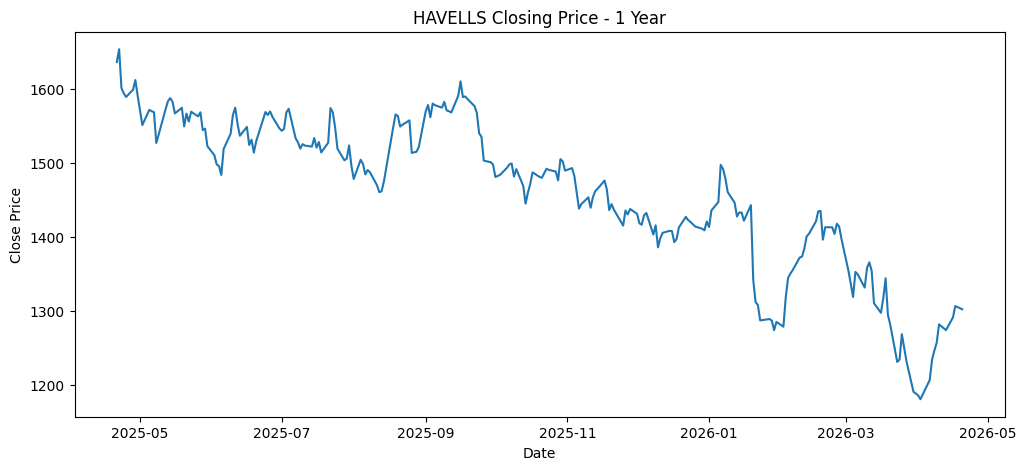

ADF Statistic: -1.875012158735993
p-value: 0.3439059233529379


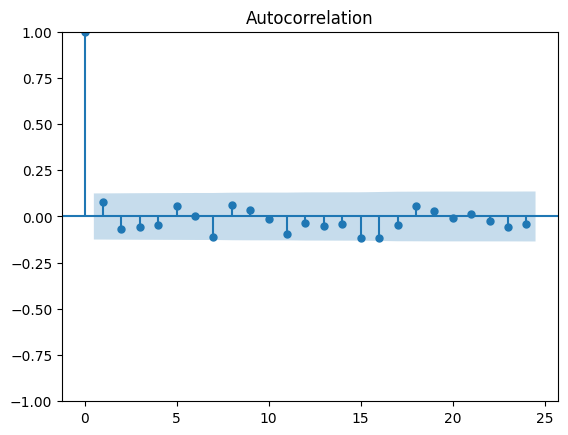

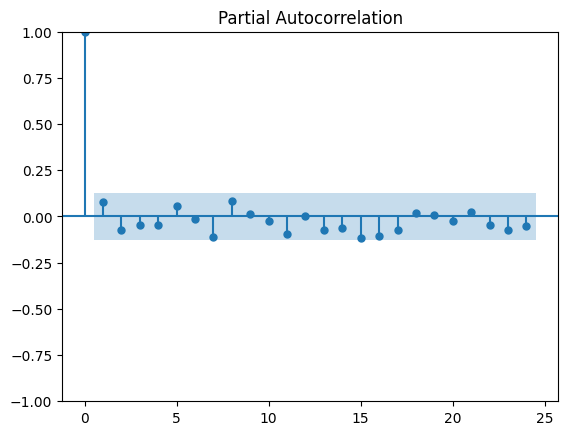

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

                               SARIMAX Results                                
Dep. Variable:             HAVELLS.NS   No. Observations:                  248
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1087.215
Date:                Mon, 20 Apr 2026   AIC                           2180.430
Time:                        15:48:41   BIC                           2190.958
Sample:                             0   HQIC                          2184.668
                                - 248                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3771      0.503     -0.749      0.454      -1.363       0.609
ma.L1          0.4712      0.483      0.975      0.329      -0.476       1.418
sigma2       389.3719     22.555     17.263      0.0

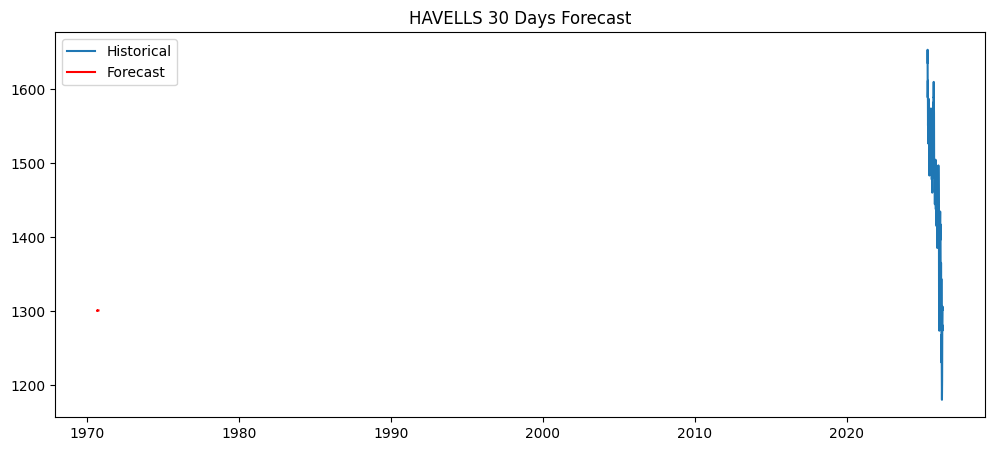

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# ----------------------
# 1. Download Data
# ----------------------
data = yf.download("HAVELLS.NS", period="1y")
data.to_csv("havells_stock.csv")

df = data.copy()

# ----------------------
# 2. Preprocessing
# ----------------------
df['Close'] = df['Close'].fillna(method='ffill')

# ----------------------
# 3. Closing Price Plot
# ----------------------
plt.figure(figsize=(12,5))
plt.plot(df['Close'])
plt.title("HAVELLS Closing Price - 1 Year")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.savefig("closing_price.png")
plt.show()

# ----------------------
# 4. ADF Test
# ----------------------
result = adfuller(df['Close'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

df['Close_diff'] = df['Close'].diff()

# ----------------------
# 5. ACF, PACF
# ----------------------
plot_acf(df['Close_diff'].dropna())
plt.savefig("acf_plot.png")
plt.show()

plot_pacf(df['Close_diff'].dropna())
plt.savefig("pacf_plot.png")
plt.show()

# ----------------------
# 6. ARIMA Model
# ----------------------
model = ARIMA(df['Close'], order=(1,1,1))
model_fit = model.fit()
print(model_fit.summary())

# ----------------------
# 7. Forecast
# ----------------------
forecast = model_fit.forecast(steps=30)
forecast_df = pd.DataFrame(forecast, columns=["Forecast"])
forecast_df.to_csv("forecast_30_days.csv")

plt.figure(figsize=(12,5))
plt.plot(df['Close'], label="Historical")
plt.plot(forecast, label="Forecast", color="red")
plt.legend()
plt.title("HAVELLS 30 Days Forecast")
plt.savefig("forecast_plot.png")
plt.show()